<a href="https://colab.research.google.com/github/0dvn/dse1/blob/main/KC_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group 1: Practical Family Buyer

## §1 EDA

### Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import dataset

In [ ]:
df = pd.read_csv('KC_housing_data 2.csv')

#### Understanding the data

In [ ]:
# Shape
df.shape

(4600, 18)

In [ ]:
# Data types
df.dtypes

,0
date,object
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64
condition,int64


In [ ]:
# Important statistics about the data
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


### Data cleaning

In [ ]:
# Find missing data
df.isna().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [ ]:
# Find duplicated data
df.loc[df.duplicated()]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country


In [ ]:
df = df[ df['price'] != 0.0 ]
df = df[ df['bedrooms'] != 0.0 ]
df = df[ df['bathrooms'] != 0.0 ]

In [ ]:
# Reset data index
df = df.reset_index(drop=True)

In [ ]:
# Verifying the data clean
df.shape

(4549, 18)

## §2 New features

#### Family friendly

In [ ]:
df['is_family_friendly'] = ((df['bedrooms'] >= 2) &
                             (df['bathrooms'] >= 2)).astype(int)


### Size category

In [ ]:
# Small (<1500)
# Medium (1500-2500)
# Large (2500-3500)
# Very Large (3500+)
df['size_category'] = pd.cut(df['sqft_living'],
                               bins=[0, 1500, 2500, 3500, float('inf')],
                               labels=['small', 'medium',
                                       'large', 'very-large'])

### Price segmentation


In [ ]:
# Budget (<$300K)
# Mid-Range ($300-500K)
# Upper-Mid ($500-750K)
# Luxury ($750K+)
df['price_segment'] = pd.cut(df['price'],
                               bins=[0, 300000, 500000, 750000, float('inf')],
                               labels=['budget', 'mid-range',
                                       'upper-mid', 'luxury'])

### Is affordable

In [ ]:
df['is_affordable'] = df['price_segment'].isin(['budget', 'mid-range']).astype(int)

### Date

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

### House age

In [ ]:
df['house_age'] = df['year'] - df['yr_built']

### Is house renovated

In [ ]:
df['is_renovated'] = (df['yr_renovated'].fillna(0).astype(int) > 0).astype(int)

### Is house flashy

In [ ]:
df['is_flashy'] = ((df['waterfront'] == 1) | (df['view'] >= 3)).astype(int)

### Price per square feet

In [ ]:
df['price_per_sqft'] = df['price'] / df['sqft_living']

### Age group

In [ ]:
# 0-10yr
# 11-20yr
# 21-30yr
# 31-50yr
# 50-100yr
# 100+yr
age_bins = [0, 10, 20, 30, 50, 100, 150]
age_labels = ['0-10yr', '11-20yr', '21-30yr', '31-50yr', '50-100yr', '100+yr']
df['age_group'] = pd.cut(df['house_age'], bins=age_bins, labels=age_labels)

## §3 Filtering for relevant data
Narrowing down to rows that satisfy the following criteria:


1.   Is family friendly
2.   Is mid-sized i.e 1500 - 2500 sqft
3.   Is affordable i.e, either budget or mid-range priced < 500,000
4.   Is not flashy



In [ ]:
criteria_mask = (
    (df['is_family_friendly'] == 1) &
    (df['size_category'] == 'medium') &
    (df['is_affordable'] == 1) &
    (df['is_flashy'] == 0)
)

df = df[criteria_mask]
print(f"Number of homes matching criteria: {len(df)}")
df = df.reset_index(drop=True)

Number of homes matching criteria: 789


In [ ]:
df.describe()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,yr_renovated,is_family_friendly,is_affordable,year,month,house_age,is_renovated,is_flashy,price_per_sqft
count,789,789.000000,789.000000,789.000000,789.000000,789.00000,789.000000,789.0,789.000000,789.000000,...,789.000000,789.000000,789.0,789.0,789.0,789.000000,789.000000,789.000000,789.0,789.000000
mean,2014-06-06 19:59:05.247148288,358550.137921,3.552598,2.407161,1967.485425,11810.65019,1.598226,0.0,0.046895,3.329531,...,1984.190114,589.122940,1.0,1.0,2014.0,5.746515,29.809886,0.295311,0.0,184.908853
min,2014-05-02 00:00:00,132250.000000,2.000000,2.000000,1510.000000,998.00000,1.000000,0.0,0.000000,1.000000,...,1901.000000,0.000000,1.0,1.0,2014.0,5.000000,0.000000,0.000000,0.0,60.333029
25%,2014-05-21 00:00:00,290256.000000,3.000000,2.250000,1730.000000,5136.00000,1.000000,0.0,0.000000,3.000000,...,1972.000000,0.000000,1.0,1.0,2014.0,5.000000,12.000000,0.000000,0.0,148.648649
50%,2014-06-09 00:00:00,351999.000000,3.000000,2.500000,1960.000000,7500.00000,2.000000,0.0,0.000000,3.000000,...,1989.000000,0.000000,1.0,1.0,2014.0,6.000000,25.000000,0.000000,0.0,176.974359
75%,2014-06-24 00:00:00,430277.777778,4.000000,2.500000,2200.000000,9680.00000,2.000000,0.0,0.000000,4.000000,...,2002.000000,1983.000000,1.0,1.0,2014.0,6.000000,42.000000,1.000000,0.0,218.009479
max,2014-07-10 00:00:00,500000.000000,7.000000,3.750000,2500.000000,435600.00000,3.000000,0.0,2.000000,5.000000,...,2014.000000,2014.000000,1.0,1.0,2014.0,7.000000,113.000000,1.000000,0.0,328.914474
std,NaN,82441.171372,0.691745,0.295132,269.999307,24512.20470,0.529147,0.0,0.296479,0.592167,...,21.933144,910.732433,0.0,0.0,0.0,0.679002,21.933144,0.456472,0.0,47.758161


## §4 Hypotheses

### Hypotheses
_Hy 1_:
Houses with at least 2 bathrooms and 3-4 bedrooms are mid-range and family-friendly.

_Hy 2_:
Recently renovated houses are in good condition, hence comfortable.


_Hy 3_:
Older houses may be more affordable than newly built homes

_Hy 4_:
House prices vary by season/month, with certain periods offering better value.


_Hy 5_:
Among family-friendly homes, price-per-square-foot varies significantly by city and house age, revealing best-value locations.

_Hy 6_:
Specific zip codes have higher concentrations of mid-range family homes, indicating established family neighborhoods with good schools and safety.

_Hy 7_:
More expensive houses are in safer neighborhoods. Houses with higher property values are clustered in specific zip codes, indicating possibly safer neighborhoods.

_Hy 8_:
Houses with luxurious spaces and have at least 2 floors or a basement are flashy.



#### Hy1: Older houses may be more affordable than newly built homes

Found partially true since it is a generic statement.

Reality: Middle-aged houses in the range 21-100 years are cheaper than newly built homes. Houses older than 100 years are more expensive because they are might be considered as vintage. This breaks the trend assumed by the hypothesis.

**21-30 year old houses** are the **cheapest** on average.


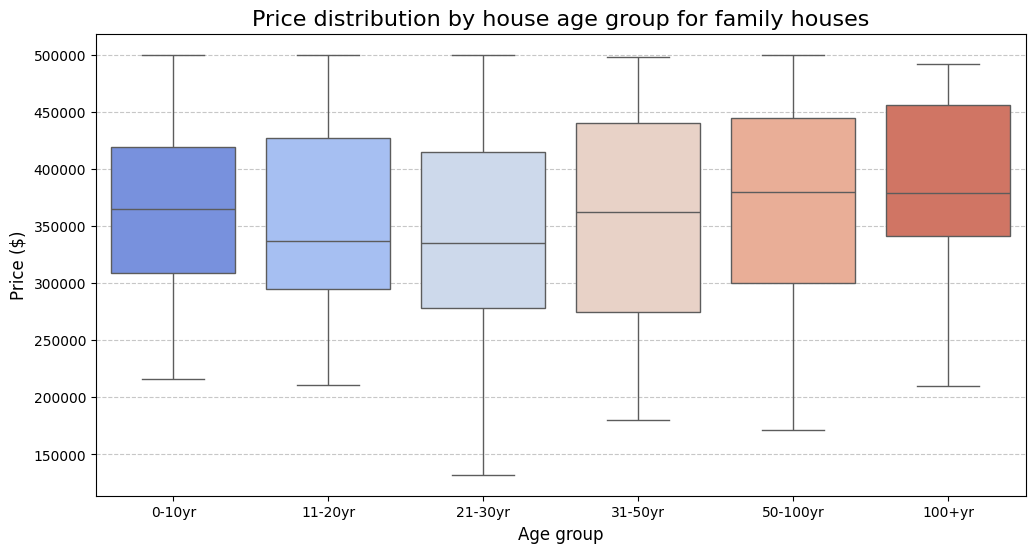

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='age_group',
            y='price',
            data=df,
            hue= 'age_group',
            legend=False,
            palette='coolwarm',
            showfliers=False)

plt.title('Price distribution by house age group for family houses', fontsize=16)
plt.ylabel('Price ($)', fontsize=12)
plt.xlabel('Age group', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

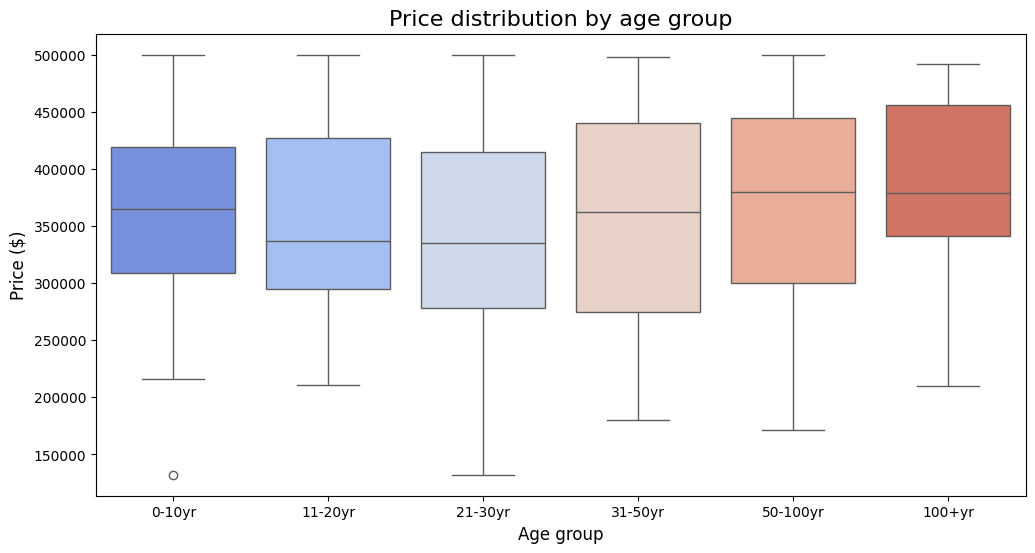

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='age_group', y='price', data=df, palette='coolwarm', hue='age_group', legend=False)
plt.title('Price distribution by age group', fontsize=16)
plt.ylabel('Price ($)', fontsize=12)
plt.xlabel('Age group', fontsize=12)
plt.show()

#### Safe neighbourhoods and Good schools
There is not specific data to reveal these details. We can only base off assumptions of family friendly homes clustering in particular areas.

##### Where are affordable family houses found?

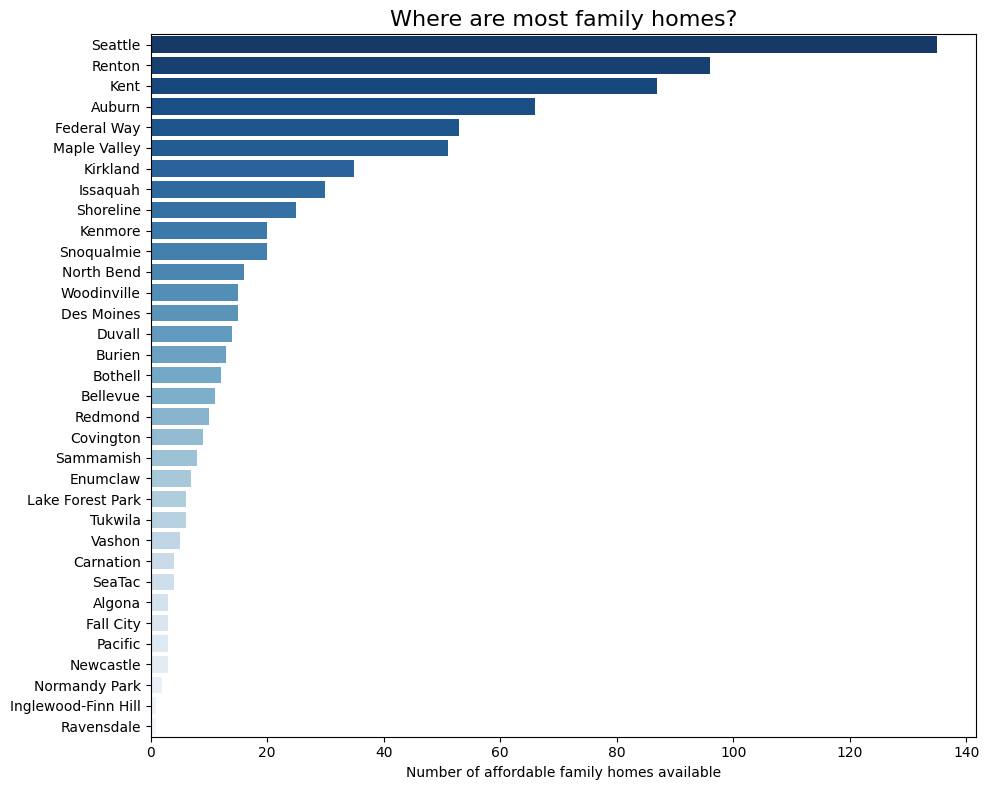

In [ ]:

city_counts = df['city'].value_counts().reset_index()
city_counts.columns = ['city', 'count']
plt.figure(figsize=(10, 8))
sns.barplot(data=city_counts, y='city', x='count', palette='Blues_r', hue='city', legend=False)
plt.title('Where are most family homes?', fontsize=16)
plt.xlabel('Number of affordable family homes available')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### What features affect price?

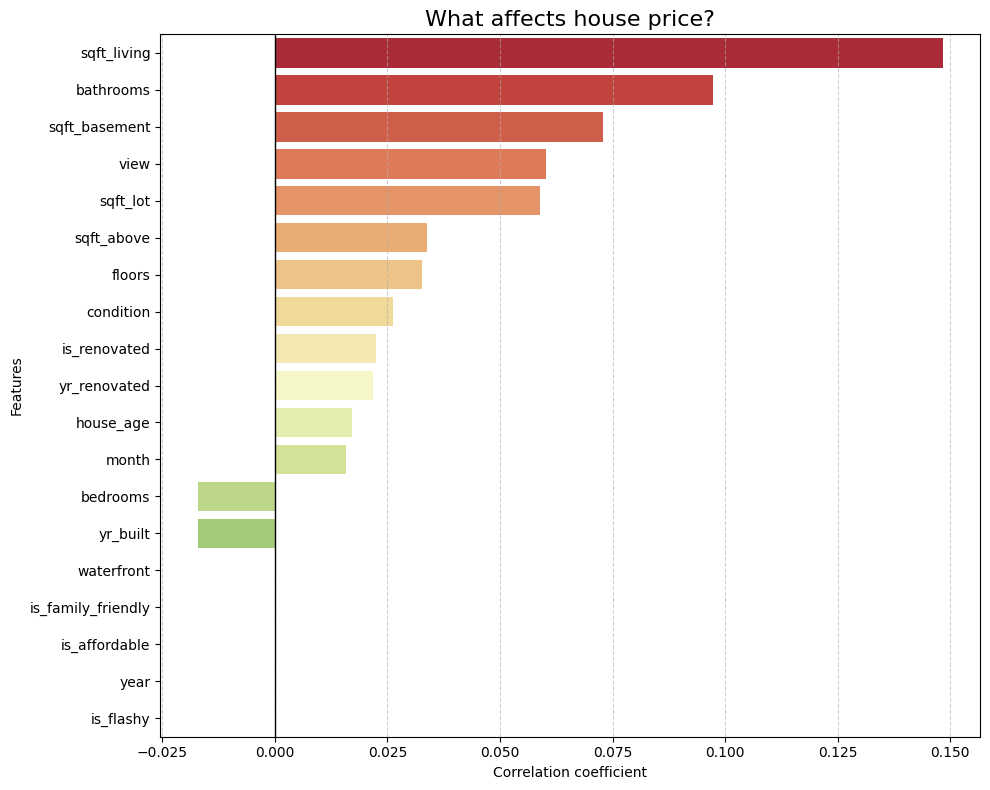

In [ ]:


numeric_df = df.select_dtypes(include=['number'])

price_correlations = numeric_df.corr()['price']
price_correlations = price_correlations.drop(['price', 'price_per_sqft'], errors='ignore')

price_correlations = price_correlations.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=price_correlations.values,
            y=price_correlations.index,
            hue=price_correlations.index,
            palette='RdYlGn',
            legend=False)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('What affects house price?', fontsize=16)
plt.xlabel('Correlation coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### When is the best time to buy?
Thes best time to buy is in May when the average price of a house is at the lowest.

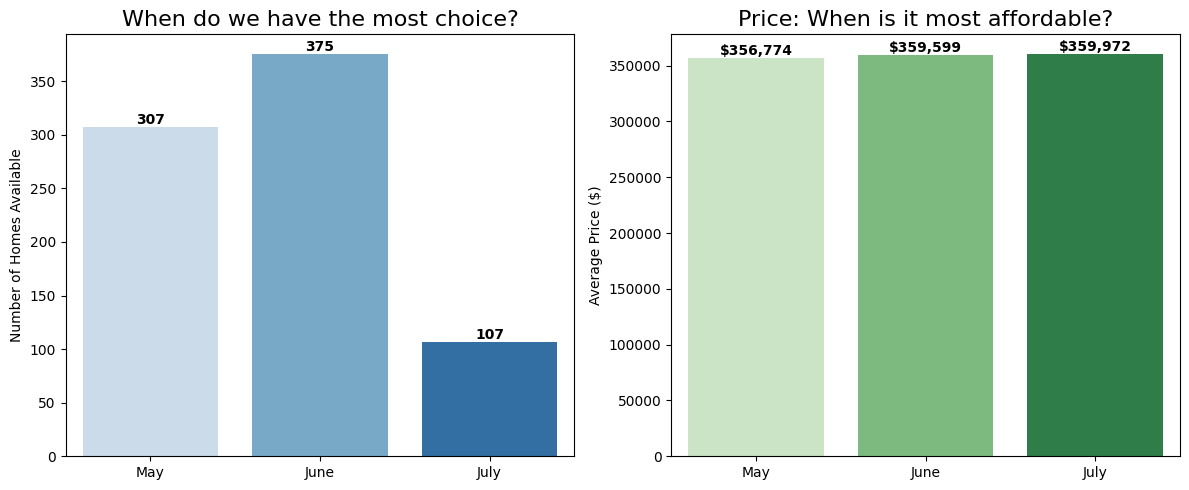

In [ ]:
monthly_stats = df.groupby('month').agg(
    Avg_Price=('price', 'mean'),
    Inventory=('price', 'count')
).reset_index()

month_map = {5: 'May', 6: 'June', 7: 'July'}
monthly_stats['Month Name'] = monthly_stats['month'].map(month_map)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=monthly_stats, x='Month Name', y='Inventory', ax=axes[0], palette='Blues', hue='Month Name', legend=False)
axes[0].set_title('When do we have the most choice?', fontsize=16)
axes[0].set_ylabel('Number of Homes Available')
axes[0].set_xlabel('')

for i, v in enumerate(monthly_stats['Inventory']):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

sns.barplot(data=monthly_stats, x='Month Name', y='Avg_Price', ax=axes[1], palette='Greens', hue='Month Name', legend=False)
axes[1].set_title('Price: When is it most affordable?', fontsize=16)
axes[1].set_ylabel('Average Price ($)')
axes[1].set_xlabel('')

for i, v in enumerate(monthly_stats['Avg_Price']):
    axes[1].text(i, v, f"${v:,.0f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

##### What is the cost of a renovated house?

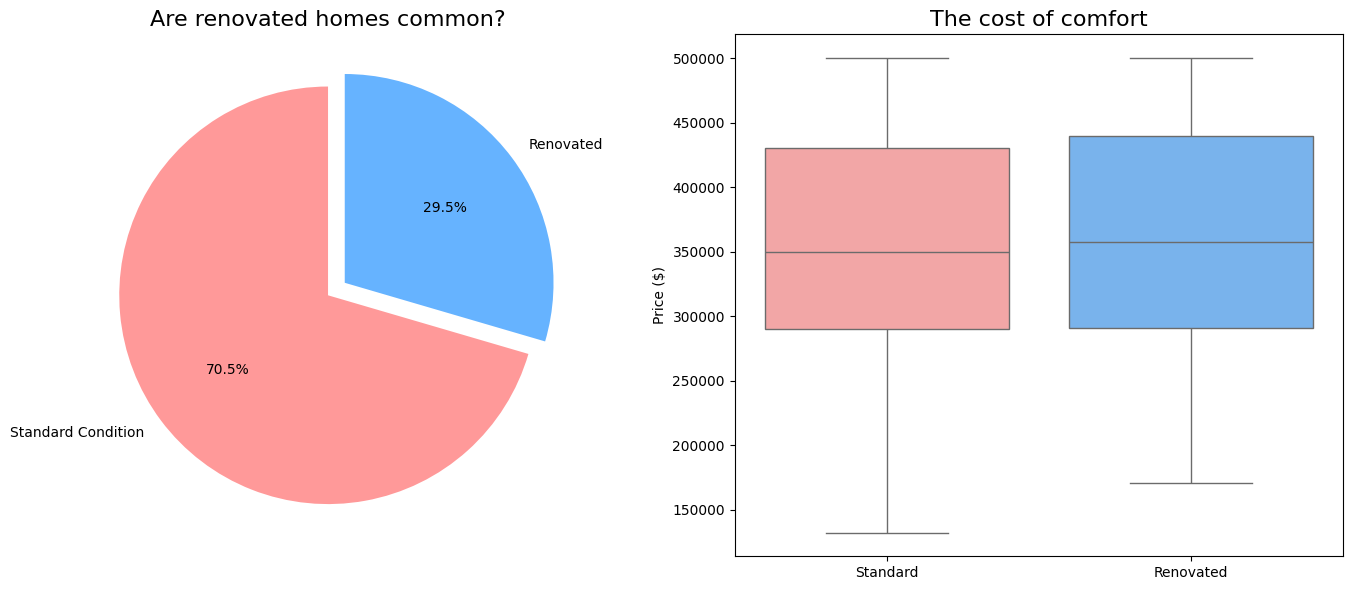

In [ ]:
blue_color_hex = '#66b3ff'
red_color_hex = '#ff9999'
colors = [red_color_hex,blue_color_hex]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
renovated_counts = df['is_renovated'].value_counts()
labels = ['Standard Condition', 'Renovated']
axes[0].pie(renovated_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0, 0.1))
axes[0].set_title('Are renovated homes common?', fontsize=16)

sns.boxplot(data=df, x='is_renovated', y='price', ax=axes[1], palette=[red_color_hex,blue_color_hex], hue='is_renovated', legend=False)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Standard', 'Renovated'])
axes[1].set_title('The cost of comfort', fontsize=16)
axes[1].set_ylabel('Price ($)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

#### Hy8: Among family-friendly homes, price-per-sqft varies significantly by city and age


##### Which city provides most value for money?


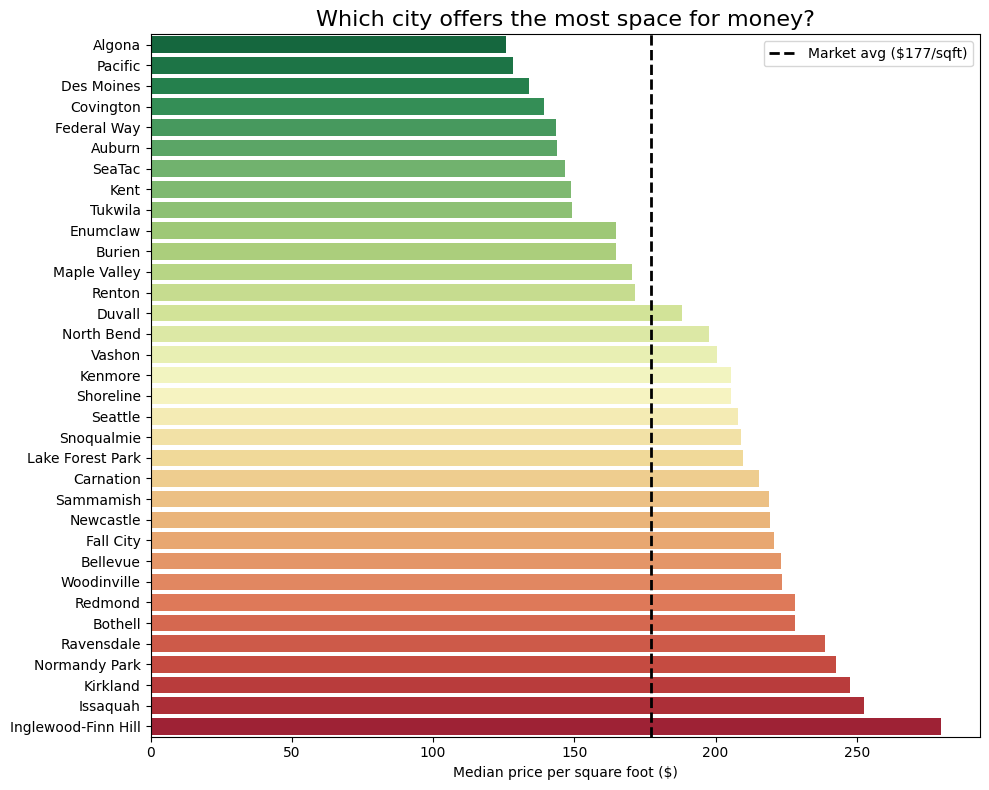

In [ ]:
city_value = df.groupby('city')['price_per_sqft'].median().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(x=city_value.values, y=city_value.index, palette='RdYlGn_r', hue=city_value.index, legend=False)
avg_pps = df['price_per_sqft'].median()
plt.axvline(avg_pps, color='black', linestyle='--', linewidth=2, label=f'Market avg (${avg_pps:.0f}/sqft)')

plt.title('Which city offers the most space for money?', fontsize=16)
plt.xlabel('Median price per square foot ($)')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

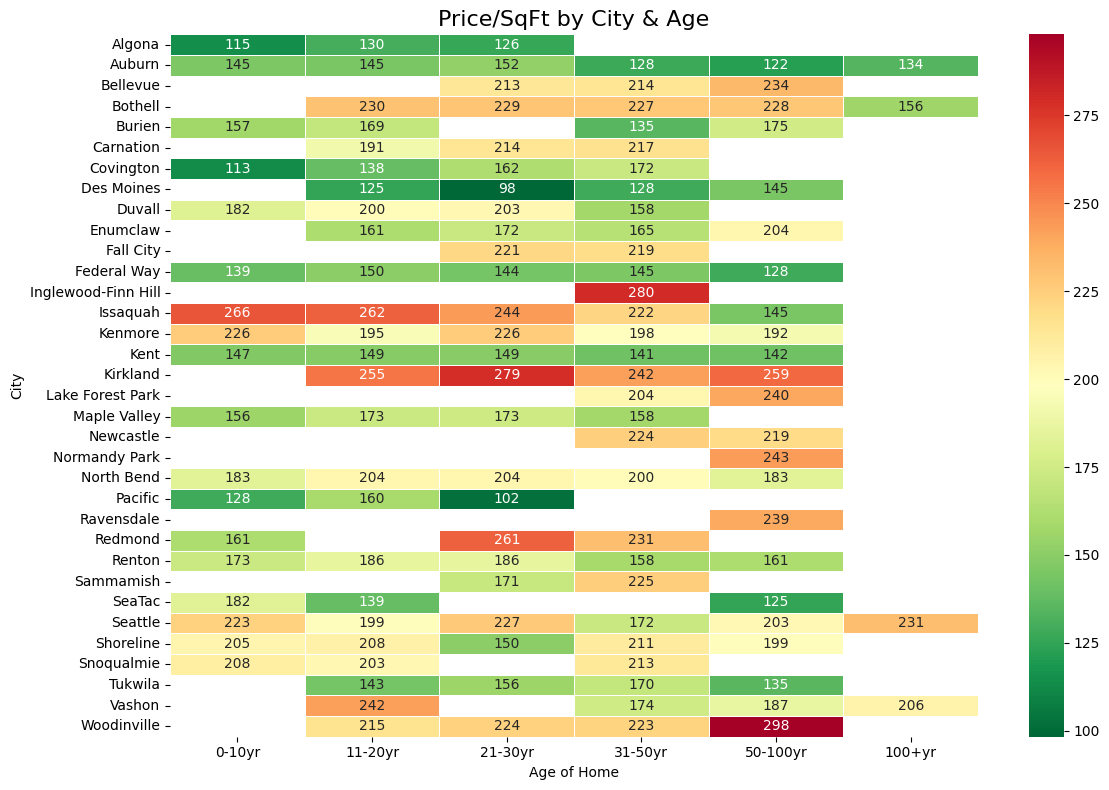

In [ ]:
pivot_table = df.pivot_table(index='city',
                             columns='age_group',
                             values='price_per_sqft',
                             observed=False,
                             aggfunc='median')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='RdYlGn_r', annot=True, fmt='.0f', linewidths=.5)
plt.title('Price/SqFt by City & Age', fontsize=16)
plt.ylabel('City')
plt.xlabel('Age of Home')
plt.tight_layout()
plt.show()

## Recommendations

The most affordable house age is 21-30 years.

Non-renovated houses are cheaper.

Most family houses are located in Seattle, Renton, Kent, Auburn, and Federal Way. Therefore getting a house in these areas could provide safety, and closer proximity to schools.

Houses are generally cheaper per square feet in Algon, Auburn, Covington, Kent, and Tukwila.

The cities in both top 5 cheapest and family-friendly are Auburn and Kent, with Auburn being cheaper.

**We can recommend non-renovated houses, in the age range 21-30 years, located in Algon or Auburn. The purchase should be made in May when the average family-friendly house price is lower.**

In [ ]:
recommendation_mask = (
    (df['is_renovated'] == 0) &
    (df['house_age'].between(21, 30)) &
    (df['city'].isin(['Algona', 'Auburn']))
)
recommended_homes = df[recommendation_mask]
if len(recommended_homes) == 0:
    print("No homes found matching these specific criteria.")
else:
    print(f"{len(recommended_homes)} found\n")

    for index, row in recommended_homes.iterrows():
        print(f"ID: {index} | City: {row['city']} | Price: ${row['price']:,.0f}")
        print(f"Details: {int(row['bedrooms'])} Bed, {row['bathrooms']} Bath | Size: {row['sqft_living']} sqft")
        print(f"Condition: Built in {int(row['yr_built'])} ({int(row['house_age'])} yrs old) | Renovated: {'Yes' if row['is_renovated'] else 'No'}")
        print("-" * 50)

7 found

ID: 272 | City: Algona | Price: $196,440
Details: 3 Bed, 2.0 Bath | Size: 1560 sqft
Condition: Built in 1992 (22 yrs old) | Renovated: No
--------------------------------------------------
ID: 368 | City: Auburn | Price: $367,300
Details: 4 Bed, 2.75 Bath | Size: 2190 sqft
Condition: Built in 1993 (21 yrs old) | Renovated: No
--------------------------------------------------
ID: 408 | City: Auburn | Price: $485,000
Details: 4 Bed, 2.5 Bath | Size: 2470 sqft
Condition: Built in 1989 (25 yrs old) | Renovated: No
--------------------------------------------------
ID: 484 | City: Auburn | Price: $280,000
Details: 3 Bed, 2.0 Bath | Size: 1790 sqft
Condition: Built in 1990 (24 yrs old) | Renovated: No
--------------------------------------------------
ID: 567 | City: Auburn | Price: $235,000
Details: 4 Bed, 2.0 Bath | Size: 1570 sqft
Condition: Built in 1984 (30 yrs old) | Renovated: No
--------------------------------------------------
ID: 631 | City: Auburn | Price: $359,500
Deta

In [ ]:
recommended_houses_in_good_timing_mask = (
    (df['is_renovated'] == 0) &
    (df['house_age'].between(21, 30)) &
    (df['city'].isin(['Algona', 'Auburn'])) &
    (df['month'] == 5)
)

recommendations_with_timing = df[recommended_houses_in_good_timing_mask]

print(f"Count of recommended homes: {len(recommendations_with_timing)}")
recommendations_with_timing

Count of recommended homes: 1


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,size_category,price_segment,is_affordable,year,month,house_age,is_renovated,is_flashy,price_per_sqft,age_group
272,2014-05-30,196440.0,3.0,2.0,1560,7352,1.0,0,0,3,...,medium,budget,1,2014,5,22,0,0,125.923077,21-30yr


## §3 Market patterns

### Market Pattern 1: Price distribution

In [ ]:
# Overall market statistics
print("TARGET MARKET STATISTICS")
print(df['price'].describe())
print(f"\nPrice Range: ${df['price'].min():,.0f} - ${df['price'].max():,.0f}")
print(f"Interquartile Range (IQR): ${df['price'].quantile(0.25):,.0f} - ${df['price'].quantile(0.75):,.0f}")

segment_distribution = df['price_segment'].value_counts()

TARGET MARKET STATISTICS


NameError: name 'df' is not defined

In [ ]:
plt.figure(figsize=(12, 6))

# Updated line: assign 'y' to 'hue' and set legend=False
sns.boxplot(x='price',
            y='price_segment',
            data=df,
            hue='price_segment',  # Explicitly map color to the segment
            palette='Blues',
            legend=False)         # Hide redundant legend

plt.title('Price Ranges per Segment')
plt.xlabel('Price ($)')
plt.ylabel('Segment')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Without outliers

plt.figure(figsize=(12, 6))

sns.boxplot(x='price',
            y='price_segment',
            data=df,
            hue='price_segment',
            palette='Blues',
            legend=False,
            showfliers=False)  # <--- This removes outliers and zooms in

plt.title('Price Ranges per Segment (Outliers Removed)')
plt.xlabel('Price ($)')
plt.ylabel('Segment')

# Optional: Format x-axis to look like currency (e.g., $500,000)
import matplotlib.ticker as ticker
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Market Pattern 2: Property Type Distribution

In [ ]:
# 1. Create the cross-tabulation
# Sort the index/columns to ensure 1.5 comes after 1.0
bed_bath_counts = pd.crosstab(df['bedrooms'], df['bathrooms']).sort_index(axis=0).sort_index(axis=1)

# 2. Plot the Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(bed_bath_counts,
            annot=True,
            fmt='d',
            cmap='YlGnBu',
            linewidths=.5,    # Add small gaps between squares for readability
            cbar_kws={'label': 'Number of Homes'})

plt.title('Frequency of Bedroom vs. Bathroom Combinations')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Number of Bedrooms')

# 3. Ensure the Y-axis starts from the bottom (standard graph behavior)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Market Pattern 3: Geographic Distribution


In [ ]:

print("=== TOP 15 CITIES BY LISTINGS ===")
city_counts = df['city'].value_counts().head(15)
print(city_counts)

print("\n=== TOP 10 MOST EXPENSIVE CITIES (Median Price) ===")
city_prices = df.groupby('city')['price'].agg(['median', 'count'])
city_prices = city_prices[city_prices['count'] >= 10]  # Filter for meaningful data
city_prices_sorted = city_prices.sort_values('median', ascending=False)
print(city_prices_sorted.head(10))

print("\n=== TOP 10 MOST AFFORDABLE CITIES (Median Price) ===")
print(city_prices_sorted.tail(10))

print(f"\n=== GEOGRAPHIC COVERAGE ===")
print(f"Total cities: {df['city'].nunique()}")
print(f"Total zipcodes: {df['statezip'].nunique()}")

In [ ]:
city_stats = df.groupby('city')['price'].median().sort_values(ascending=False)

num_cities = len(city_stats)
fig_height = max(6, num_cities * 0.3)

plt.figure(figsize=(10, fig_height))

plt.barh(city_stats.index, city_stats.values, color='skyblue', edgecolor='black', alpha=0.8)

plt.title('Complete Market Affordability Ranking (Median Price)')
plt.xlabel('Median Price ($)')
plt.ylabel('City')

plt.grid(axis='x', linestyle='--', alpha=0.6)

import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

### Market Pattern 4: Property Age Distribution


In [ ]:
print("=== PROPERTY AGE STATISTICS ===")
print(df['house_age'].describe())

print("\n=== AGE DISTRIBUTION ===")
print(df['age_group'].value_counts().sort_index())

renovation_rate = (df['yr_renovated'] > 0).mean() * 100
print(f"\n=== RENOVATION STATISTICS ===")
print(f"Homes that have been renovated: {renovation_rate:.1f}%")

In [ ]:
plt.figure(figsize=(12, 6))
age_group_counts = df['age_group'].value_counts().sort_index()
age_group_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Property Count by House Age Group')
plt.xlabel('House Age Group')
plt.ylabel('Number of Properties')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Market Pattern 5: Supply & Demand Indicators


In [ ]:
print("=== INVENTORY BY MARKET SEGMENT ===")
inventory_by_segment = df.groupby('price_segment').size()
print(inventory_by_segment)
print(f"\n{(inventory_by_segment / len(df) * 100).round(1)}% of market")

print("\n=== INVENTORY BY SIZE/BEDROOM ===")
size_bed_inventory = df.groupby(['size_category', 'bedrooms']).size().unstack(fill_value=0)
print(size_bed_inventory)

date_range = df['date'].max() - df['date'].min()
print(f"\n=== DATASET TIME RANGE ===")
print(f"From: {df['date'].min().date()}")
print(f"To: {df['date'].max().date()}")
print(f"Duration: {date_range.days} days")

sales_by_month = df.groupby(df['date'].dt.to_period('M')).size()
print(f"\n=== AVERAGE MONTHLY SALES ===")
print(f"Average sales per month: {sales_by_month.mean():.0f} homes")

=== INVENTORY BY MARKET SEGMENT ===


NameError: name 'df' is not defined

In [ ]:
# 3. Heatmap: Bedroom vs Size inventory
plt.figure(figsize=(10, 8))
sns.heatmap(size_bed_inventory, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Inventory Heatmap: Size Category vs Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Size Category')
plt.tight_layout()
plt.show()